In [87]:
# Dogs vs Cats Data Load
import os
import pandas as pd

train_df = pd.DataFrame({'file': os.listdir('./train')})
train_df['label'] = train_df['file'].apply(lambda x: x.split('.')[0])

train_df.head()

,file,label
0,cat.9117.jpg,cat
1,cat.9069.jpg,cat
2,cat.9099.jpg,cat
3,cat.9072.jpg,cat
4,cat.9100.jpg,cat


In [88]:
# Data Split
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(train_df,
                                         test_size=0.2,
                                         random_state=13)

In [89]:
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

train_data.head()

,file,label
0,cat.5919.jpg,cat
1,cat.3260.jpg,cat
2,cat.230.jpg,cat
3,dog.7366.jpg,dog
4,dog.8399.jpg,dog


In [90]:
# Make Dataset
# DataFrame에 이미지의 이름과 Label이 담겨있음
# 이를 불러와서 Dataset으로 만드는 클래스
from PIL import Image

from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

class CatDogDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.dataframe.loc[idx, 'file'])
        image = Image.open(img_name)
        label = 1 if self.dataframe.loc[idx, 'label'] == 'dog' else 0

        if self.transform:
            image = self.transform(image)

        return image, label

# Transform for ToTensor
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = CatDogDataset(train_data,
                              root_dir='./train',
                              transform=transform)
test_dataset = CatDogDataset(test_data,
                             root_dir='./train',
                             transform=transform)

In [91]:
# Data Loader
# 왜 625장?
# -> 이미지 총 25000장에서 test_size=0.2, batch_size=64
# -> 25000 * 0.8 / 32 = 625
batch_size = 32

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=4,
                          pin_memory=True)
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False,
                         num_workers=4,
                         pin_memory=True)

print(f'Train Loader: {len(train_loader)}')
print(f'Test Loader: {len(test_loader)}')

Train Loader: 625
Test Loader: 157


In [92]:
# VGG16 Model Load
import torch
import torch.nn as nn
import torchvision.models as models

vgg16 = models.vgg16(weights=True)
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [93]:
# VGG16 분류기
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [94]:
# VGG16 분류기의 첫번째 Layer의 입력 개수
vgg16.classifier[0].in_features

25088

In [95]:
# VGG16 CNN Layer만 사용하고 분류기는 수정
class TransferVGG16(nn.Module):
    def __init__(self, num_classes=2):
        super(TransferVGG16, self).__init__()

        self.vgg16 = models.vgg16(weights=True)

        # CNN Layer는 학습 x
        for param in self.vgg16.features.parameters():
            param.requires_grad = False

        # 분류기 수정
        num_features = self.vgg16.classifier[0].in_features
        self.vgg16.classifier = nn.Sequential(
            nn.Linear(num_features, 1000),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1000, num_classes)
        )

        # 분류기 Layer는 학습 o
        for param in self.vgg16.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.vgg16(x)

TransferVGG16()

TransferVGG16(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      

In [96]:
# !pip install torchinfo

In [97]:
# Model Summary
from torchinfo import summary

model = TransferVGG16()

device = torch.device('cuda')
model = model.to(device)

summary(model,
        input_size=(batch_size, 3, 224, 224),
        device=device)

Layer (type:depth-idx)                   Output Shape              Param #
TransferVGG16                            [32, 2]                   --
├─VGG: 1-1                               [32, 2]                   --
│    └─Sequential: 2-1                   [32, 512, 7, 7]           --
│    │    └─Conv2d: 3-1                  [32, 64, 224, 224]        (1,792)
│    │    └─ReLU: 3-2                    [32, 64, 224, 224]        --
│    │    └─Conv2d: 3-3                  [32, 64, 224, 224]        (36,928)
│    │    └─ReLU: 3-4                    [32, 64, 224, 224]        --
│    │    └─MaxPool2d: 3-5               [32, 64, 112, 112]        --
│    │    └─Conv2d: 3-6                  [32, 128, 112, 112]       (73,856)
│    │    └─ReLU: 3-7                    [32, 128, 112, 112]       --
│    │    └─Conv2d: 3-8                  [32, 128, 112, 112]       (147,584)
│    │    └─ReLU: 3-9                    [32, 128, 112, 112]       --
│    │    └─MaxPool2d: 3-10              [32, 128, 56, 56]   

In [98]:
# Model Compile
model = TransferVGG16()

device = torch.device('cuda')
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [99]:
# Train
from tqdm import tqdm

def test(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100. * correct / total
    return accuracy

num_epochs = 3
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=True)
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        loop.set_postfix(loss=loss.item())

    # train_accuracy = test(model, train_loader, device)
    test_accuracy = test(model, test_loader, device)

    epoch_loss = running_loss / len(train_loader.dataset)

    # print(f'Epoch: {epoch + 1} | Train Loss: {epoch_loss} | Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}')
    print(f'Epoch: {epoch + 1} | Train Loss: {epoch_loss} | Test Accuracy: {test_accuracy}')

print('Training Finish')

Epoch 1/3: 100%|██████████| 625/625 [05:38<00:00,  1.85it/s, loss=0.0978]


Epoch: 1 | Train Loss: 0.1853735452904366 | Test Accuracy: 95.76


Epoch 2/3: 100%|██████████| 625/625 [02:08<00:00,  4.86it/s, loss=0.0126]


Epoch: 2 | Train Loss: 0.0783195633925905 | Test Accuracy: 96.76


Epoch 3/3: 100%|██████████| 625/625 [02:06<00:00,  4.95it/s, loss=0.0337]


Epoch: 3 | Train Loss: 0.07654447511909529 | Test Accuracy: 96.62
Training Finish


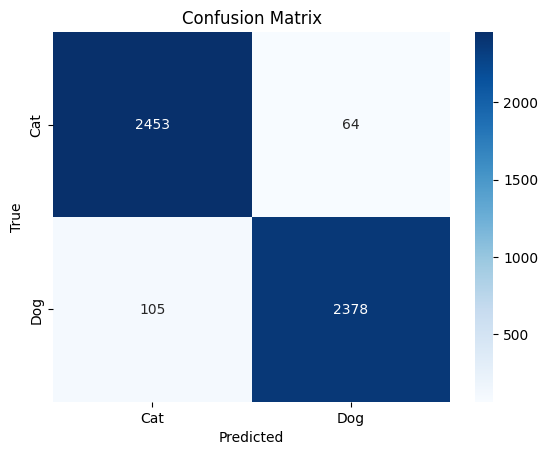

In [100]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    _, predicted = torch.max(outputs.data, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()